# ENTREGA FINAL - VISUALIZACÓN OBJETIVO SECUNDARIO OS02
## OS02 – ruido, salud y bienestar (escala local y nacional)

El OS-02 busca explorar de manera descriptiva la relación entre la exposición al ruido ambiental y distintos indicadores agregados de salud y bienestar, tanto a nivel local como nacional. 

La visualización integra la exposición al ruido con indicadores agregados de salud y bienestar a escala local y nacional, permitiendo identificar patrones y diferencias entre territorios mediante un enfoque exploratorio y correlacional, condicionado por la agregación y disponibilidad de los datos.

La visualización se organiza en dos bloques principales de análisis:
* BLOQUE 1: Bloque de integración de datos de ruido y bienestar (escala nacional y local). Visualizaciones que combinan variables de ruido e indicadores de calidad de vida, permitiendo su análisis conjunto en términos evolutivos o contextuales.
* BLOQUE 2: Bloque de análisis comparativo entre variables. Visualizaciones orientadas a explorar posibles asociaciones mediante representaciones multivariantes, facilitando la identificación de patrones sin establecer relaciones causales.


Para el análisis del Objetivo Secundario 02 ruido, salud y bienestar (local y nacional) se han seleccionado estas fuentes de datos que permiten vincular la exposición al ruido con indicadores oficiales de salud y bienestar:
* df01: Madrid – Contaminación acústica (SIVCA) - datos diarios (LAeq, L10/L50/L90/L99). 
* df02: Madrid – Contaminación acústica, históricos mensuales (1998–). 
* df03: Define los límites normativos aplicables en España en franjas horarias y entornos.
* df07: Indicadores de evolución de la calidad de vida.






Para el análisis del OS02 se realizan las siguientes visualizaciones asociadas:

1. BLOQUE 1: Bloque de integración de datos de ruido y bienestar (escala nacional y local).
    * VISUALIZACIÓN OS02-01: Diagrama de dispersión temporal (scatter plot) que representa la evolución conjunta del ruido (variable principal) y la calidad de vida (representada mediante el color) a escala nacional.
    * VISUALIZACIÓN OS02-02: Serie temporal que representa la evolución del nivel medio de ruido en Madrid.
    * VISUALIZACIÓN OS02-03: Serie temporal multivariante que representa la evolución de distintas dimensiones del bienestar en Madrid.


2. BLOQUE 2: Bloque de análisis comparativo entre variables.
    * VISUALIZACIÓN OS02-04: Mapa de calor (heatmap) comparativo temporal que representa la superación de los umbrales de ruido por periodo, permitiendo analizar la intensidad y frecuencia de incumplimientos normativos en el tiempo. 
    * VISUALIZACIÓN OS02-05: Mapa de calor (heatmap) multivariable temporal que representa la evolución de las dimensiones de bienestar por año, facilitando la identificación de patrones temporales diferenciados entre variables. La intensidad relativa (representada por el color) facilita la identificación de patrones temporales y cambios estructurados entre dimensiones.
      


Para ello se propone representaciones, análisis y correlaciones que permiten:

* Analizar niveles de ruido (df_01, df_02)
* Compararlos con indicadores de bienestar (df_07)
* Ver tendencias temporales y espaciales
* Explorar correlaciones, no causalidad

* PREPRARACIÓN DE ENTORNO

In [1]:
import altair as alt

# Desactivar vegafusion
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [2]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [3]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

# file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
# file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
#file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
#file_path_06_locales = "df_06_locales_terrazas_processed.csv"
file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
# file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"

# df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
#df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )


In [4]:
# convertimos el campo fecha
# df_01_ruido_diario["fecha"] = pd.to_datetime(df_01_ruido_diario["fecha"])
df_01_daily["fecha"] = pd.to_datetime(df_01_daily["fecha"])
df_01_daily_plot["fecha"] = pd.to_datetime(df_01_daily_plot["fecha"])

In [5]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [6]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [7]:
df_01_daily.dtypes

fecha      datetime64[ns]
periodo            object
laeq              float64
dtype: object

In [8]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [9]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [10]:
df_07_Mad_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,hoja
0,"Madrid, Comunidad de",99.281388,99.073928,98.995333,99.861205,99.068609,98.366696,98.653084,99.268873,98.964064,99.541366,100.490067,101.042230,100.341117,100.244256,100.663699,100.694292,100.392714,Dimensión 1
1,"Madrid, Comunidad de",102.443179,101.286922,100.068555,98.786346,98.199386,97.217032,97.754106,98.176490,98.303559,99.467470,101.094265,102.040018,101.949573,101.896527,102.562630,103.439218,104.155571,Dimensión 2
2,"Madrid, Comunidad de",103.489366,103.026299,103.103050,103.627108,105.494034,102.491987,105.122979,105.432678,106.334012,108.513085,105.886130,108.111280,104.024469,104.006636,106.388545,104.335901,105.449334,Dimensión 3
3,"Madrid, Comunidad de",104.808559,104.300917,105.974979,108.170192,107.496162,108.298555,107.807106,108.089664,108.526886,108.651639,108.892133,109.861059,111.008167,112.861069,113.545969,112.890669,113.492921,Dimensión 4
4,"Madrid, Comunidad de",101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,101.086655,102.394647,102.394647,102.394647,99.109254,99.109254,99.109254,98.552799,95.350110,95.407400,95.204588,Dimensión 5


In [11]:
df_07_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total Nacional,100.000000,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
1,Andalucía,98.243355,97.380868,96.050234,95.873410,96.286384,95.622403,93.873830,95.430977,95.109237,97.657589,96.327075,97.800458,97.531583,96.583852,97.405337,96.848018,97.669293
2,Aragón,104.665521,105.104032,104.671560,103.980765,103.854998,101.243728,102.009913,103.563863,103.507154,104.988320,105.015362,105.160684,104.967605,103.561554,104.365009,103.033659,102.971541
3,"Asturias, Principado de",104.694153,104.117801,104.823618,104.799107,104.114874,102.477116,102.114463,101.598634,103.343305,102.808435,103.194704,101.713544,101.577220,102.199418,102.777763,102.421108,103.144408
4,"Balears, Illes",98.671469,97.180334,97.344712,96.118689,96.990238,95.750127,95.020305,95.348632,99.342930,97.257662,100.872675,101.463459,100.802315,98.925490,99.182382,99.454337,100.680923


In [12]:
df_07_evo_Q_vida.head()

,dim,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Global,100,99.634569,99.965132,100.259843,100.162563,99.910831,100.089989,100.366085,100.650384,101.096816,101.584055,101.906592,101.633697,101.559293,101.138772,101.202614,101.467223
1,1. Condiciones materiales de vida,100,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
2,2. Trabajo,100,98.345879,97.299442,95.990293,95.026675,94.076989,94.485209,95.273782,96.111272,97.231544,98.958235,99.747189,99.923761,99.627699,100.830857,101.756664,102.335092
3,3. Salud,100,99.225387,100.231553,101.656364,101.568570,100.552128,101.827690,101.969652,102.607827,103.568939,102.881003,103.869402,102.048269,101.298106,103.069806,101.855348,103.285736
4,4. Educación,100,100.110585,101.174039,101.844575,102.276487,102.844659,102.597361,103.020490,103.350113,103.840667,104.547002,105.032833,105.865870,108.420165,108.998673,109.567866,110.112882


In [13]:
df_07_evo_long_Q_vida.head()

,dim,año,valor_evolucion,dim_num
0,Global,2008,100.0,NaN
1,1. Condiciones materiales de vida,2008,100.0,1.0
2,2. Trabajo,2008,100.0,2.0
3,3. Salud,2008,100.0,3.0
4,4. Educación,2008,100.0,4.0


## BLOQUE 1 - Visualizaciones de integración de datos de ruido y bienestar (escala nacional y local)

Este bloque agrupa aquellas visualizaciones que permiten analizar conjuntamente la evolución de la exposición al ruido y los indicadores de bienestar. Con el objetivo de analizar tendencias temporales en dimensiones de ruido y bienestar, además de permitir observar posibles coincidencias o divergencias en su comportamiento.

* VISUALIZACIÓN OS02-01: Diagrama de dispersión temporal (scatter plot) que representa la evolución conjunta del ruido (variable principal) y la calidad de vida (representada mediante el color) a escala nacional.
* Las visualizaciones OS02-02 y 03 son series temporales coordinadas.
* VISUALIZACIÓN OS02-02: Serie temporal que representa la evolución del nivel medio de ruido en Madrid.
* VISUALIZACIÓN OS02-03: Serie temporal multivariante que representa la evolución de distintas dimensiones del bienestar en Madrid.



#### VISUALIZACIÓN OS02-01: Exposición al ruido vs calidad de vida (escala nacional)
 Objetivo de la visualización: Explorar y cuantificar la relación temporal entre el nivel medio de ruido nocturno y el índice agregado de calidad de vida a escala nacional, identificando patrones de asociación a lo largo del periodo 2014–2024.
 
* TIPO DE GRÁFICO: Scatter plot. Diagrama de dispersión interactivo con burbujas (mark_circle), donde el eje X representa el año, el eje Y el nivel medio de ruido nocturno (Ln), y el color y tamaño de las burbujas codifican el índice de calidad de vida.

Justificación El gráfico de dispersión con codificación múltiple permite analizar simultáneamente la evolución temporal, la intensidad del ruido nocturno y el nivel de bienestar agregado, facilitando la identificación de tendencias, concentraciones y posibles asociaciones indirectas entre ruido ambiental y calidad de vida, sin implicar causalidad.

* DATOS datasets utilizados:
* * Ruido: df_01_daily
* * Bienestar: df_07_Q_vida
* Columnas utilizadas:
* * Ruido (df_01_daily): fecha, periodo, laeq
* * Bienestar (df_07_Q_vida): CCAA, columnas 2008 … 2024

HIPÓTESIS: A mayores niveles de exposición al ruido ambiental, los indicadores agregados de calidad de vida tienden a ser menores.



In [14]:
#Usamos LAeq nocturno (periodo == 'N'), ya que el ruido nocturno es el más relacionado con efectos sobre la salud y el bienestar.

# --- RUIDO: media anual de LAeq nocturno ---
df_ruido_anual_nocturno = (
    df_01_daily
    .query("periodo == 'N'")
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_nocturno=("laeq", "mean"))
)

df_ruido_anual_nocturno.head()

,año,laeq_nocturno
0,2014,55.508328
1,2015,56.779824
2,2016,57.029914
3,2017,57.014522
4,2018,56.758120


In [15]:
# Bienestar – df_07_Q_vida: Nos quedamos con Total Nacional
# Se pasa a formato long (año, indice_calidad_vida)

# --- BIENESTAR: Total Nacional en formato largo ---
df_calidad_vida_long = (
    df_07_Q_vida
    .query("CCAA == 'Total Nacional'")
    .drop(columns=["CCAA"])
    .melt(var_name="año", value_name="indice_calidad_vida")
)

df_calidad_vida_long["año"] = df_calidad_vida_long["año"].astype(int)

df_calidad_vida_long.head()


,año,indice_calidad_vida
0,2008,100.000000
1,2009,99.171134
2,2010,98.761457
3,2011,99.304088
4,2012,98.663408


In [16]:
# Obtenermos el dataset final para la visualización - df_os02_01

# --- MERGE FINAL (por año) ---
df_os02_01 = df_ruido_anual_nocturno.merge(df_calidad_vida_long, on="año", how="inner")

df_os02_01.head()

,año,laeq_nocturno,indice_calidad_vida
0,2014,55.508328,97.666577
1,2015,56.779824,98.261476
2,2016,57.029914,98.552239
3,2017,57.014522,99.666386
4,2018,56.758120,100.448144


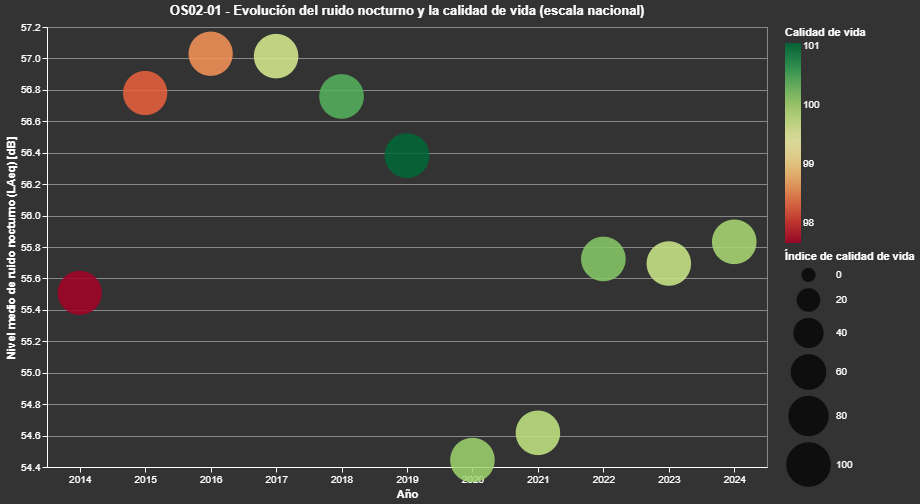

In [17]:
# Visualización OS02‑01 (Scatter plot)
# X → Exposición al ruido (LAeq nocturno medio anual)
# Y → Índice de calidad de vida nacional
# Punto → un año
# Tooltip → año + valores exactos

# Calcular explícitamente el rango del índice de calidad de vida
min_cv = df_os02_01["indice_calidad_vida"].min()
max_cv = df_os02_01["indice_calidad_vida"].max()

scatter_os02_01_time_color = (
    alt.Chart(df_os02_01)
    .mark_circle(opacity=0.85)
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("laeq_nocturno:Q", title="Nivel medio de ruido nocturno (LAeq) [dB]", scale=alt.Scale(zero=False)),
        size=alt.Size("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(range=[200, 2000])),
        color=alt.Color("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(scheme="redyellowgreen",
                domain=[min_cv, max_cv]  # ⬅ control explícito
            ),
            legend=alt.Legend(title="Calidad de vida", orient="right")
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("laeq_nocturno:Q", title="LAeq nocturno [dB]", format=".2f"),
            alt.Tooltip("indice_calidad_vida:Q", title="Índice de calidad de vida", format=".2f")
        ]
    )
    .properties(
        width=720, height=440,
        title="OS02-01 - Evolución del ruido nocturno y la calidad de vida (escala nacional)"
    )
)

scatter_os02_01_time_color

CONCLUSIONES DE LA VISUALIZACION OS02-01: 

Los años con mayor exposición media al ruido nocturno tienden a asociarse con valores más bajos del índice agregado de calidad de vida, sugiriendo una relación negativa entre presión acústica y bienestar.

### VISUALIZACIÓN OS02-02 y OS02-03: Evolución temporal: ruido vs bienestar (Madrid)
Objetivo de la visualización: Explorar la evolución temporal conjunta del ruido ambiental medio y de los indicadores de bienestar en la Comunidad de Madrid, analizando si las variaciones en la presión acústica coinciden con cambios en los niveles de bienestar.

* TIPO DE GRÁFICO: Small multiples / líneas sincronizadas. Small multiples de gráficos de líneas sincronizadas (mark_line), con dos paneles alineados verticalmente y eje temporal compartido (año).

Justificación: El uso de gráficos de líneas sincronizados permite comparar de forma directa las tendencias temporales del ruido y del bienestar, facilitando la identificación visual de posibles paralelismos, divergencias o desacoples entre ambas variables sin inducir interpretaciones causales.
  
* DATOS - Datasets:
* * Ruido: df_01_daily_plot
* * Bienestar Madrid: df_07_Mad_Q_vida
* Columnas usadas:
* * Ruido: fecha, NMT, laeq. Se agregan media anual de laeq (promedio de estaciones)
* * Bienestar Madrid: columnas 2008 … 2024, hoja (dimensiones)

* Diseño: del gráfico - datos representados:
* Gráfico 1: evolución del ruido medio anual
* Gráfico 2: evolución índice de bienestar Madrid
* Eje X compartido (año)

* HIPÓTESIS: Las variaciones en la presión acústica a lo largo del tiempo coinciden con cambios en los indicadores de bienestar en la Comunidad de Madrid.

In [18]:
#Obtenermos el ruido medio anual en madrid, promediando todas las estaciones.

# Asegurar formato fecha
df_01_daily_plot["fecha"] = pd.to_datetime(df_01_daily_plot["fecha"])

# ---- RUIDO: media anual de LAeq (promedio de estaciones) ----
df_ruido_madrid_anual = (
    df_01_daily_plot
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_medio=("laeq", "mean"))
)

df_ruido_madrid_anual.head()

,año,laeq_medio
0,2014,59.652561
1,2015,60.824524
2,2016,60.895810
3,2017,60.885756
4,2018,60.637140


In [19]:
#Calculamos el bienestar en Madrid. Para obtener la evolución temporal del índice de calidad de vida por dimensiones
# ---- BIENESTAR MADRID en formato largo ----
df_bienestar_madrid_long = (
    df_07_Mad_Q_vida
    .drop(columns=["CCAA"])
    .rename(columns={"hoja": "dimension"})
    .melt(
        id_vars="dimension",
        var_name="año",
        value_name="indice_calidad_vida"
    )
)

df_bienestar_madrid_long["año"] = df_bienestar_madrid_long["año"].astype(int)

df_bienestar_madrid_long.head()

,dimension,año,indice_calidad_vida
0,Dimensión 1,2008,99.281388
1,Dimensión 2,2008,102.443179
2,Dimensión 3,2008,103.489366
3,Dimensión 4,2008,104.808559
4,Dimensión 5,2008,101.086655


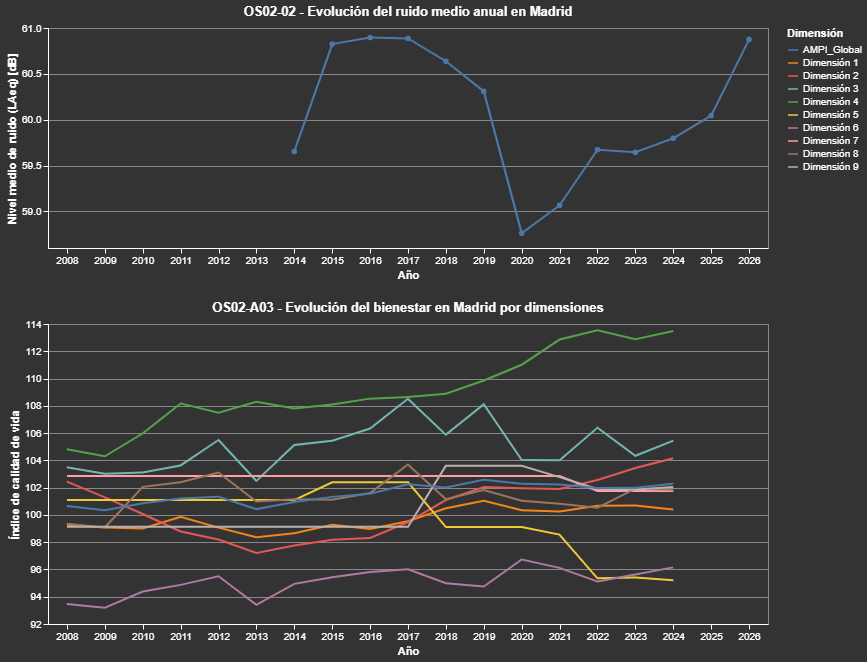

In [20]:
#VISUALIZACIÓN OS02-02 y OS02-03: Dos gráficos. 
#(1) OS02-03: Ruido medio anual en Madrid.
#(2) OS02-03: Evolución del bienestar por dimensiones

# -------------------------
# Gráfico 1, OS02-02: Ruido medio anual
# -------------------------
chart_ruido = (
    alt.Chart(df_ruido_madrid_anual).mark_line(point=True)
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("laeq_medio:Q", title="Nivel medio de ruido (LAeq) [dB]", scale=alt.Scale(zero=False)),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("laeq_medio:Q", title="LAeq medio", format=".2f")
        ]
    )
    .properties(width=720, height=220, title="OS02-02 - Evolución del ruido medio anual en Madrid")
)

# -------------------------
# Gráfico 2, OS02-03: Bienestar Madrid (por dimensiones)
# -------------------------
chart_bienestar = (
    alt.Chart(df_bienestar_madrid_long)
    .mark_line()
    .encode(
        x=alt.X("año:O", title="Año", axis=alt.Axis(labelAngle=0)),
        y=alt.Y("indice_calidad_vida:Q", title="Índice de calidad de vida", scale=alt.Scale(zero=False)),
        color=alt.Color("dimension:N", title="Dimensión"),
        tooltip=[
            alt.Tooltip("dimension:N", title="Dimensión"),
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("indice_calidad_vida:Q", title="Índice", format=".2f")
        ]
    )
    .properties(width=720, height=300, title="OS02-A03 - Evolución del bienestar en Madrid por dimensiones")
)

# -------------------------
# Visualización final OS02-02 + OS02-03
# -------------------------
vis_os02_02_03 = alt.vconcat(chart_ruido, chart_bienestar).resolve_scale(x="shared")

vis_os02_02_03

In [21]:
#LITERALES DE LAS DIMENSIONES
#Las dimensiones del bienestar se identifican mediante sus literales completos (salud, educación, trabajo, etc.), 
#extraídos directamente del dataset de evolución del índice de calidad de vida.
dimensiones_literales = (df_07_evo_Q_vida["dim"].dropna().unique().tolist())
dimensiones_literales

['Global',
 '1. Condiciones materiales de vida',
 '2. Trabajo',
 '3. Salud',
 '4. Educación',
 '5. Ocio y relaciones sociales',
 '6. Seguridad física y personal',
 '7. Gobernanza y derechos básicos',
 '8. Entorno y medioambiente',
 '9. Experiencia general de la vida']

##	BLOQUE 2 - Visualizaciones de análisis comparativo entre variables

Este bloque agrupa las visualizaciones que permiten realizar un análisis más directamente orientado a la comparación entre variables, utilizando representaciones multivariantes.

* VISUALIZACIÓN OS02-04: Mapa de calor (heatmap) comparativo temporal que representa la superación de los umbrales de ruido por periodo, permitiendo analizar la intensidad y frecuencia de incumplimientos normativos en el tiempo. 
* VISUALIZACIÓN OS02-05: Mapa de calor (heatmap) multivariable temporal que representa la evolución de las dimensiones de bienestar por año, facilitando la identificación de patrones temporales diferenciados entre variables. La intensidad relativa (representada por el color) facilita la identificación de patrones temporales y cambios estructurados entre dimensiones.


### VISUALIZACIÓN OS02-04: Ruido nocturno y superación de límites de salud
Objetivo de la visualización: Evaluar el grado en que el ruido nocturno ambiental supera los umbrales legales y recomendados para la salud, cuantificando su frecuencia e intensidad a lo largo del tiempo como factor de riesgo para el bienestar.


* TIPO DE GRÁFICO: Bar chart y heatmap. Combinación de gráfico de barras (mark_bar) y mapa de calor (mark_rect), sincronizados temporalmente, con codificación cromática de la intensidad de superación del límite nocturno.
* Justificación: El uso combinado de barras y heatmap permite analizar de forma complementaria la evolución temporal del porcentaje de superaciones del límite nocturno y la intensidad media del ruido, facilitando la identificación de patrones persistentes de incumplimiento normativo relevantes para la salud pública.

* DATOS - Datasets:
* * Ruido: df_02_cont_acustic
* * Normativa: df_03_noise_lim
* Columnas utilizadas:
* * Ruido: ln, fecha, estacion. Se agregan media anual de ln y % de registros que superan el límite nocturno
* * Normativa: noiselevelindicator = lnight, limitvalue

* Diseño del gráfico: El color en heatmap indica intensidad de superación.
* HIPÓTESIS: El ruido nocturno supera con mayor frecuencia los umbrales recomendados para la salud, lo que refuerza su potencial impacto negativo sobre el bienestar.

In [22]:
#recuperamos el valor de límite nocturno según la normativa. 
#Se obtiene de df_03_noise_lim
# -----------------------------------
# LÍMITE NOCTURNO (Ln) SEGÚN NORMATIVA
# -----------------------------------
limite_ln = (
    df_03_noise_lim
    .query("noiselevelindicator == 'lnight' and limitvaluedefined_bool == True")
    ["limitvalue"]
    .iloc[0]
)

limite_ln

np.float64(50.0)

El anterior resultado implica el siguiente valor de límite nocturno:

LIMITE NOCTURNO = 50dB

In [23]:
# -----------------------------------
# RUIDO NOCTURNO PROCESADO
# -----------------------------------
df_02_cont_acustic["fecha"] = pd.to_datetime(df_02_cont_acustic["fecha"])

df_ruido_ln = (df_02_cont_acustic.dropna(subset=["ln"]).assign(año=lambda d: d["fecha"].dt.year,
        supera_limite=lambda d: d["ln"] > limite_ln ))

# Agregación anual
df_ln_anual = (df_ruido_ln.groupby("año", as_index=False)
    .agg(ln_medio=("ln", "mean"), pct_superacion=("supera_limite", "mean") )
)

# Pasamos a porcentaje
df_ln_anual["pct_superacion"] *= 100

df_ln_anual.head()

,año,ln_medio,pct_superacion
0,2015,57.257097,90.000000
1,2016,57.769086,91.129032
2,2017,57.706486,91.891892
3,2018,57.444355,92.204301
4,2019,57.098922,91.913747


In [24]:
# Diseño del Heatmap (OS02‑04)
# Codificación visual: Eje X → Año. Eje Y → Métrica acústica
# Ln medio % superación del límite

# Color → Intensidad del problema (más oscuro = peor)
# Tooltip → valores exactos

df_ln_heatmap = df_ln_anual.melt(id_vars="año", value_vars=["ln_medio", "pct_superacion"],
    var_name="métrica", value_name="valor")

# Etiquetas legibles
df_ln_heatmap["métrica"] = df_ln_heatmap["métrica"].map({
    "ln_medio": "Ln medio [dB]", "pct_superacion": "% de superación del límite"
})

df_ln_heatmap.head()

,año,métrica,valor
0,2015,Ln medio [dB],57.257097
1,2016,Ln medio [dB],57.769086
2,2017,Ln medio [dB],57.706486
3,2018,Ln medio [dB],57.444355
4,2019,Ln medio [dB],57.098922


In [25]:
heatmap_os02_04 = (
    alt.Chart(df_ln_heatmap)
    .mark_rect()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "métrica:N",
            title=""
        ),
        color=alt.Color(
            "valor:Q",
            title="Intensidad",
            scale=alt.Scale(scheme="reds")
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip("métrica:N", title="Indicador"),
            alt.Tooltip("valor:Q", title="Valor", format=".2f")
        ]
    )
    .properties(
        width=720,
        height=200,
        title=(
            "OS02-04 -Ruido nocturno y superación de límites de salud\n"
            f"Límite nocturno de referencia: {limite_ln} dB"
        )
    )
)

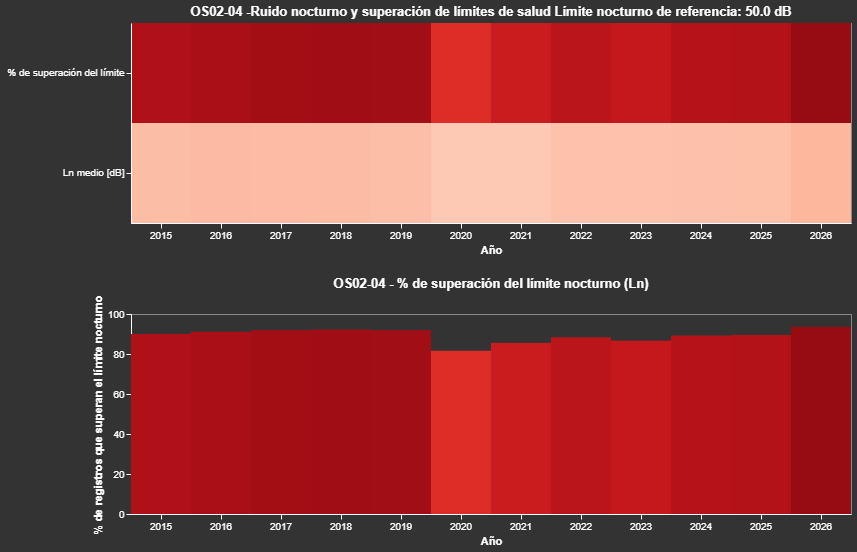

In [26]:
#Bar chart: % de superación del límite nocturno
# usando el valor calculado %: df_ln_anual["pct_superacion"]

bars_os02_04 = (
    alt.Chart(df_ln_anual)
    .mark_bar()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "pct_superacion:Q",
            title="% de registros que superan el límite nocturno",
            scale=alt.Scale(domain=[0, 100])
        ),
        color=alt.Color(
            "pct_superacion:Q",
            scale=alt.Scale(scheme="reds"),
            legend=None
        ),
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "pct_superacion:Q",
                title="% superación",
                format=".1f"
            )
        ]
    )
    .properties(
        width=720,
        height=200,
        title="OS02-04 - % de superación del límite nocturno (Ln)"
    )
)

vis_os02_04 = alt.vconcat(
    heatmap_os02_04,
    bars_os02_04
).resolve_scale(x="shared")

vis_os02_04

En la visualización OS02‑04, tanto el nivel medio de ruido nocturno como el porcentaje de registros que superan el límite sanitario recomendado se representan mediante una escala cromática en tonos rojos. Esta elección refuerza la lectura conjunta del fenómeno, enfatizando la persistencia y la intensidad de la superación de los umbrales nocturnos asociados a potenciales efectos adversos sobre la salud.

### VISUALIZACIÓN OS02-05: Bienestar por dimensiones vs ruido
 OBJETIVO: Explorar la evolución temporal de las distintas dimensiones del bienestar y destacar los años con mayor exposición acústica, analizando la posible sensibilidad diferencial de las dimensiones relacionadas con salud y entorno frente al ruido.
 * Se identificarán años de mayor ruido.
* HIPÓTESIS: Las dimensiones relacionadas con salud y entorno muestran mayor sensibilidad frente a contextos de mayor exposición acústica.

 
* TIPO DE GRÁFICO: Heatmap. Mapa de calor (heatmap) (mark_rect) con líneas verticales superpuestas como anotaciones temporales para señalar años de elevada exposición acústica.

Justificación: El heatmap permite comparar de forma sintética la evolución del bienestar por dimensiones a lo largo del tiempo, mientras que la señalización de los años con mayor ruido facilita identificar coincidencias visuales entre contextos de alta exposición acústica y cambios en los indicadores de bienestar, sin inferir causalidad.

* DATOS - Datasets: Datos de bienestar en formato largo procedentes de df_07_evo_long_Q_vida (dimensión, año, valor_evolucion) y niveles de ruido nocturno agregados anualmente a partir de df_01_daily, utilizados para identificar los años de mayor exposición acústica.
* * df_07_evo_long_Q_vida
* * Ruido agregado anual (df_01_daily)
  * 
* Columnas utilizadas:
* * Bienestar: dim, año, valor_evolucion
* Diseño del gráfico: 
* * Eje X → año
* * Eje Y → dimensión (Salud, Entorno, Educación…)
* Color → según el valor del índice

In [27]:
#Preparación de los datos
#Bienestar – df_07_evo_long_Q_vida: Columnas disponibles (en formato largo):
# * dim → literal de la dimensión (Salud, Educación, Trabajo…)
# * año
# * valor_evolucion

df_bienestar = df_07_evo_long_Q_vida.copy()

# Ruido agregado anual – df_01_daily
# Columnas utilizadas: fecha, periodo, laeq

# Decisión metodológica según el OS02: 
# * Usamos ruido nocturno (periodo == 'N')
# * Calculamos media anual
# * Identificamos años de mayor ruido (percentil 75)

# Asegurar formato fecha
df_01_daily["fecha"] = pd.to_datetime(df_01_daily["fecha"])

# Ruido nocturno anual
df_ruido_anual = (
    df_01_daily
    .query("periodo == 'N'")
    .assign(año=lambda d: d["fecha"].dt.year)
    .groupby("año", as_index=False)
    .agg(laeq_nocturno=("laeq", "mean"))
)

# Umbral de años con mayor ruido (percentil 75)
umbral_ruido = df_ruido_anual["laeq_nocturno"].quantile(0.75)

df_ruido_anual["alto_ruido"] = df_ruido_anual["laeq_nocturno"] >= umbral_ruido

df_ruido_anual.head()

,año,laeq_nocturno,alto_ruido
0,2014,55.508328,False
1,2015,56.779824,True
2,2016,57.029914,True
3,2017,57.014522,True
4,2018,56.758120,False


In [28]:
#Visualización base: Heatmap de bienestar
# Eje X → Año. Eje Y → Dimensión de bienestar (literal). Color → Valor del índice (valor_evolucion)

heatmap_bienestar = (
    alt.Chart(df_bienestar)
    .mark_rect()
    .encode(
        x=alt.X(
            "año:O",
            title="Año",
            axis=alt.Axis(labelAngle=0)
        ),
        y=alt.Y(
            "dim:N",
            title="Dimensión de bienestar"
        ),
        color=alt.Color(
            "valor_evolucion:Q",
            title="Índice de bienestar",
            scale=alt.Scale(scheme="redyellowgreen")
        ),
        tooltip=[
            alt.Tooltip("dim:N", title="Dimensión"),
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "valor_evolucion:Q",
                title="Índice",
                format=".2f"
            )
        ]
    )
    .properties(
        width=720,
        height=300,
        title="OS02 - Evolución del bienestar por dimensiones"
    )
)

In [29]:
# Señalización de años con mayor ruido
# Para mostrar los años de mayor ruido, añadimos líneas verticales sobre esos años.

lineas_ruido = (
    alt.Chart(df_ruido_anual[df_ruido_anual["alto_ruido"]])
    .mark_rule(color="red", strokeDash=[4, 2], opacity=0.7)
    .encode(
        x="año:O",
        tooltip=[
            alt.Tooltip("año:O", title="Año"),
            alt.Tooltip(
                "laeq_nocturno:Q",
                title="LAeq nocturno",
                format=".2f"
            )
        ]
    )
)

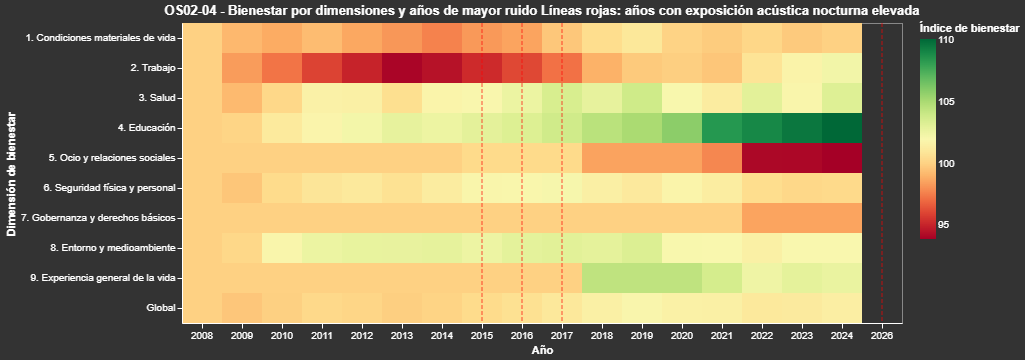

In [30]:
#VISUALIZACIÓN FINAL: VIS_OS02_04
vis_os02_04 = (
    heatmap_bienestar + lineas_ruido
).properties(
    title=(
        "OS02‑04 - Bienestar por dimensiones y años de mayor ruido\n"
        "Líneas rojas: años con exposición acústica nocturna elevada"
    )
)

vis_os02_04


El heatmap OS02‑04 muestra la evolución temporal de las distintas dimensiones del bienestar, mientras que las líneas verticales señalan los años con mayor exposición acústica nocturna. Esta combinación permite explorar si dimensiones como salud y entorno presentan variaciones más acusadas en contextos de mayor ruido, apoyando la hipótesis de una mayor sensibilidad del bienestar a la presión acústica.

#### CONCLUSIONES Y ANÁLISIS DEL OBJETIVO SECUNDARIO 02 (OS-02)

El análisis de OS02 permite integrar la evolución del ruido y de los indicadores de bienestar desde una perspectiva agregada, evidenciando dinámicas temporales diferenciadas pero comparables, que sitúan el ruido dentro de un sistema más amplio de condiciones de vida. 

Sin embargo, la exploración de relaciones entre variables muestra la ausencia de patrones lineales consistentes, con una elevada dispersión que refleja la complejidad del fenómeno y la influencia de factores adicionales. Las visualizaciones multivariantes permiten identificar diferencias entre dimensiones de bienestar y evoluciones no homogéneas en el tiempo, así como patrones observables, pero no generalizables.

En conjunto, el análisis facilita la integración y comparación de variables, manteniendo un enfoque exploratorio, descriptivo y no causal, condicionado por la naturaleza agregada de los datos y la heterogeneidad de las fuentes.



In [ ]:
%whos